#**GDG TASK 2**

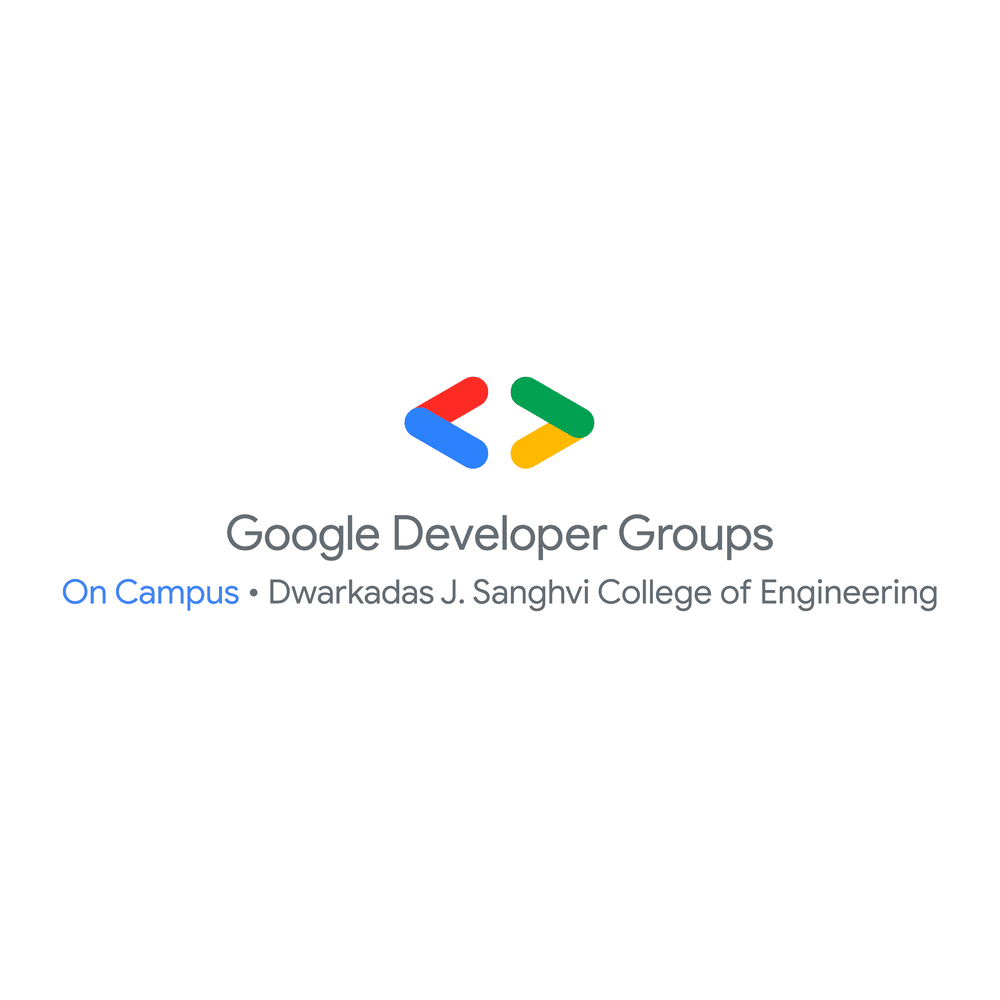

Last week, we dealt with the visualization and analytical aspect of ML. This week, lets directly get our hands dirty with various ML models.

Possibly the first question one must ask is, what is Machine Learning essentially made up of? In a broad sense, ML problems can be split into Supervised and Unsupervised learning. In supervised learning are the categories of Classification and Regression, which is what we'll explore today.

Like last time, resources and comments are provided above each cell, so peruse the resources and then get coding.

Supervised vs Unsupervised vs Reinforcement Learning:

https://www.simplilearn.com/tutorials/machine-learning-tutorial/types-of-machine-learning

Regression vs Classification :

https://www.analyticsvidhya.com/blog/2023/05/regression-vs-classification/ (Might be a little wordy)

https://www.youtube.com/watch?v=1NBwM5tavTk&ab_channel=IntuitiveML
(A very quick video)

Machine Learning for Everyone (Read till 1.1):

https://vas3k.com/blog/machine_learning/

OPTIONAL BUT USEFUL <br>
Overfitting and Underfitting [VERY IMPORTANT]
https://www.youtube.com/watch?v=T9NtOa-IITo

Lets import all the basic libraries.

In [ ]:
!pip install shap -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

##Regression

For regression, lets reuse the crab dataset that you worked on last week. Import the dataset from wherever you had saved it in the cell below.
Also print the first 5 rows to ensure you have loaded the dataset correctly.

In [ ]:
# read dataset

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Task1_processed.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Now, let's some employ some Feature Engineering tactics which you would have performed in the previous tasks.

Create a function called crab_processing which takes a dataframe as an input, performs the following tasks, and returns a cleaned and edited df:

1) Drop the 'id' column.

2) Drop all rows where 'Height' of the crab is 0.

3) Create a new column called 'LostWeight' which is calculated using the following formula - ```
Weight - (Shucked + Viscera + Shell)``` .
If this formula gives a number less than 0, then assign 0 to the LostWeight column, else assign 1.

4) Finally, use one hot encoding to encode the column 'Sex'

Take help from your previous task where you have implemented these steps in different cells.


In [ ]:
# Your code ends here
df

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Age,Lost_weight,Sex_F,Sex_I,Sex_M,charges_bin
0,1.5250,1.1750,0.3750,28.973189,12.728926,6.647958,8.348928,9,1.247378,0,1,0,2
1,1.1000,0.8250,0.2750,10.418441,4.521745,2.324659,3.401940,8,0.170097,0,1,0,0
2,1.3875,1.1125,0.3750,24.777463,11.339800,5.556502,6.662133,9,1.219029,0,0,1,2
3,1.7000,1.4125,0.5000,50.660556,20.354941,10.991839,14.996885,11,4.316891,1,0,0,3
4,1.2500,1.0125,0.3375,23.289114,11.977664,4.507570,5.953395,8,0.850485,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74022,1.6625,1.2625,0.4375,50.660556,20.680960,10.361742,12.332033,10,7.285821,1,0,0,3
74023,1.0750,0.8625,0.2750,10.446791,4.323299,2.296310,3.543687,6,0.283495,0,1,0,0
74024,1.4875,1.2000,0.4125,29.483480,12.303683,7.540967,8.079607,10,1.559222,1,0,0,2
74025,1.2125,0.9625,0.3125,16.768729,8.972617,2.919999,4.280774,8,0.595340,0,1,0,1


In [ ]:
df.columns

Index(['Length', 'Diameter', 'Height', 'Weight', 'Shucked Weight',
       'Viscera Weight', 'Shell Weight', 'Age', 'Lost_weight', 'Sex_F',
       'Sex_I', 'Sex_M', 'charges_bin'],
      dtype='object')

In [ ]:
lost_weight_raw = df['Weight'] - (df['Shucked Weight'] + df['Viscera Weight'] + df['Shell Weight'])

In [ ]:
lost_weight_raw

,0
0,1.247378
1,0.170097
2,1.219029
3,4.316891
4,0.850485
...,...
74022,7.285821
74023,0.283495
74024,1.559222
74025,0.595340


In [ ]:
import pandas as pd

def crab_preprocessing(df_input):
    if 'id' in df_input.columns:
        df_input = df_input.drop('id', axis=1)

    df_input = df_input[df_input['Height'] != 0].copy()

    calculated_lost_weight_raw = df_input['Weight'] - (df_input['Shucked Weight'] + df_input['Viscera Weight'] + df_input['Shell Weight'])
    df_input['Lost_weight'] = calculated_lost_weight_raw.apply(lambda x: 0 if x < 0 else 1)

    # Given the input 'df' already has 'Sex_F', 'Sex_I', 'Sex_M', this block might not execute if 'Sex' is already removed.
    if 'Sex' in df_input.columns:
        df_input = pd.get_dummies(df_input, columns=['Sex'], drop_first=False)

    return df_input

df_crab = crab_preprocessing(df)

In [ ]:
df_crab = df_crab[df_crab['Age'] != 0].copy()


If all is correct, this should be the shape of your df now.

In [ ]:
df_crab.shape

(74027, 13)

###Basic Visualization

In this problem, our aim is to predict the age of the crab, hence 'Age' here is called our target variable. To check its distribution, plot a histogram of the 'Age' column.

Choose the number of bins by experimenting. The output is expected to mimic a bell curve.

What is a histogram? - https://www.w3schools.com/python/matplotlib_histograms.asp

Difference between histogram and a bar graph - https://keydifferences.com/difference-between-histogram-and-bar-graph.html

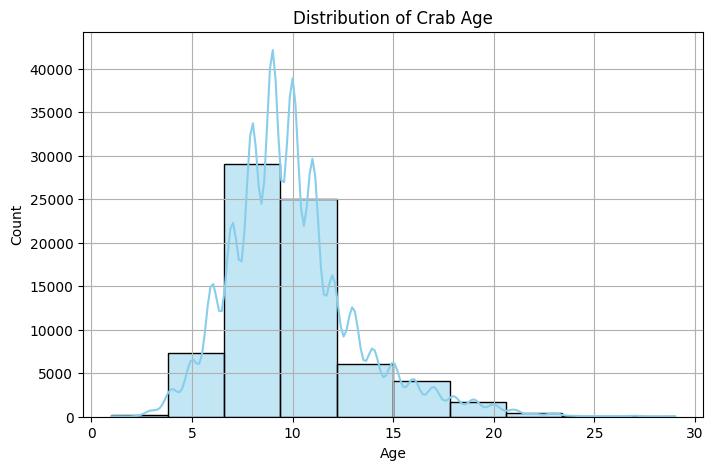

In [ ]:
# Your code starts here
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=10, kde=True, color='skyblue') #
plt.title('Distribution of Crab Age')
plt.xlabel('Age')
plt.ylabel('Count')
# plt.grid(True)
plt.show()

# Your code ends here

###Feature and Variable Sets

As mentioned above, the 'Age' column is what we're gonna be predicting. So essentially we need to create two additional dataframes, one which contains all the training features (All columns except 'Age') and one which only contains the column 'Age'. Name them X and y respectively.

In [ ]:
# Your code starts here
X = df.drop("Age",axis=1)
y = df[["Age"]]

# Your code ends here

In [ ]:
y

,Age
0,9
1,8
2,9
3,11
4,8
...,...
74022,10
74023,6
74024,10
74025,8


In [ ]:
X

,Length,Diameter,Height,Weight,Shucked Weight,Viscera Weight,Shell Weight,Lost_weight,Sex_F,Sex_I,Sex_M,charges_bin
0,1.5250,1.1750,0.3750,28.973189,12.728926,6.647958,8.348928,1.247378,0,1,0,2
1,1.1000,0.8250,0.2750,10.418441,4.521745,2.324659,3.401940,0.170097,0,1,0,0
2,1.3875,1.1125,0.3750,24.777463,11.339800,5.556502,6.662133,1.219029,0,0,1,2
3,1.7000,1.4125,0.5000,50.660556,20.354941,10.991839,14.996885,4.316891,1,0,0,3
4,1.2500,1.0125,0.3375,23.289114,11.977664,4.507570,5.953395,0.850485,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
74022,1.6625,1.2625,0.4375,50.660556,20.680960,10.361742,12.332033,7.285821,1,0,0,3
74023,1.0750,0.8625,0.2750,10.446791,4.323299,2.296310,3.543687,0.283495,0,1,0,0
74024,1.4875,1.2000,0.4125,29.483480,12.303683,7.540967,8.079607,1.559222,1,0,0,2
74025,1.2125,0.9625,0.3125,16.768729,8.972617,2.919999,4.280774,0.595340,0,1,0,1


In [ ]:
y.isnull().sum()

,0
Age,0


In [ ]:
# This code should print (74003, 11) and (74003, 1) if everything is correct
print(X.shape)
print(y.shape)

(74027, 12)
(74027, 1)


In [ ]:
#Print a few records of X

In [ ]:
#Print a few records of y

###Train-Test Split

Implementation - https://www.youtube.com/watch?v=BUkqYGPnLZ8&ab_channel=ManifoldAILearning

Now, while we need data to train our regression model, it is equally important to keep some data aside for testing the effectiveness of the aforementioned model. Thus the dataset as a whole is generally further divided into the training dataset and the testing dataset.

In order to implement this, import train_test_split function from scikit-learn.

In [ ]:
# Import train_test_split Hint: Use sklearn.model_selection
from sklearn.model_selection import train_test_split



**Create X and y train and test splits in one command using a test size of 0.3 and a random seed**

They should be called X_train, X_test, y_train, y_test

In [ ]:
# Your code starts here
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Your code ends here

Print the size and shape of each of the train/test splits (it should be in the ratio as per test_size parameter above, i.e in ratio of 0.3)

In [ ]:
# Your code starts here
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print()
print("X_train size:", X_train.size)
print("X_test size:", X_test.size)
print("y_train size:", y_train.size)
print("y_test size:", y_test.size)


# Your code ends here

X_train shape: (51818, 12)
X_test shape: (22209, 12)
y_train shape: (51818, 1)
y_test shape: (22209, 1)

X_train size: 621816
X_test size: 266508
y_train size: 51818
y_test size: 22209


Can you see that the data has been divided into 2 datasets of size 70% and 30% of the original dataset each? Use your calculator to confirm this :)

###Model fit and training

Here is the complete lowdown on SVM (Support Vector Machine):<br>
Theory : https://youtu.be/H9yACitf-KM <br>
Theory: https://www.analyticsvidhya.com/blog/2021/06/support-vector-machine-better-understanding/ <br>
Implementation : https://youtu.be/FB5EdxAGxQg

Import SVR (Support Vector Regressor) and its metrics from scikit-learn.

In [ ]:
# Add your import statement here
from sklearn.svm import SVR
svr = SVR()
# Create an SVR object 'svr' by calling SVR()

Fit the model on to the instantiated object itself using the X_train and y_train created earlier. No need to create another variable.

Hint: svr.fit()

This might take about a minute or so, just to inform you.

In [ ]:
# Your code starts here
svr.fit(X_train,y_train.values.ravel())
# Your code ends here

SVR()

###Prediction, error estimate, and regression evaluation matrices

**Prediction using the svr model**

The X_train and y_train dataframes have been used to train the model. Now we will use X_test and y_test to evaluate the efficiency of the model we have trained.

Use svr.predict() on X_test and store it in a variable called "predictions". Print type and size of the predictions.

Size should be (22201,) if everything is correct.

In [ ]:
# Your code starts here
predictions = svr.predict(X_test)

# Print type and size
print(type(predictions))
print(predictions.shape)
# Your code ends here

<class 'numpy.ndarray'>
(22209,)


Now that we have our predictions, let's compare it with y_test and see how accurate our predictions are.

Plot a Scatter plot of predicted price and y_test set to see if the data falls on a 45 degree straight line

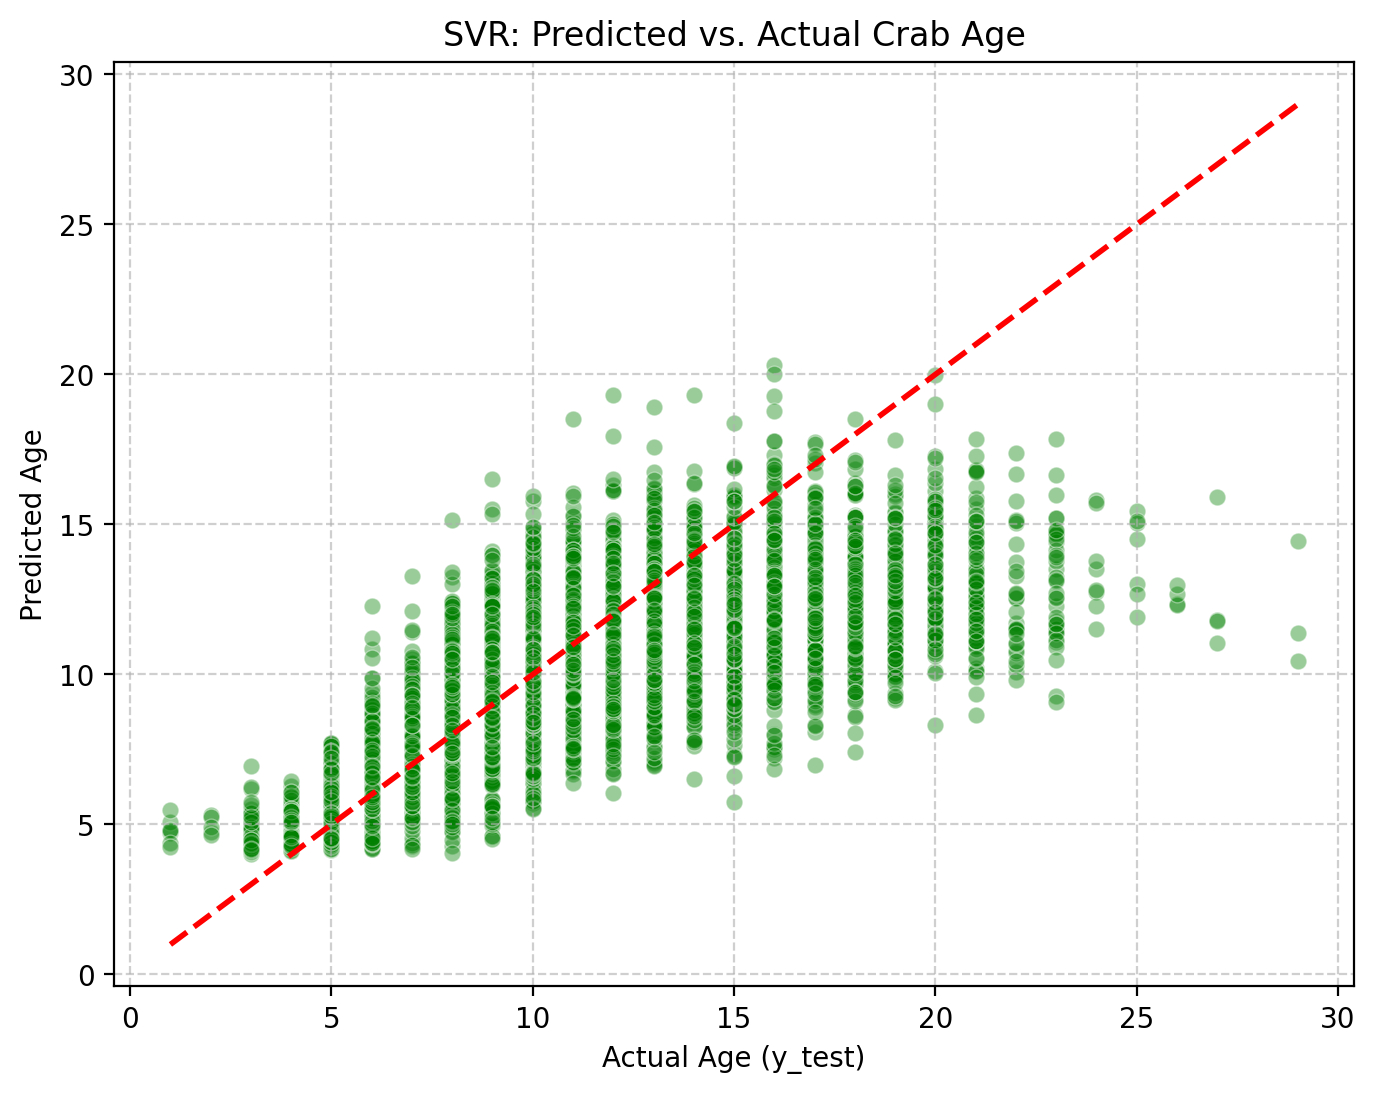

In [ ]:
# Your code starts here
plt.figure(figsize=(8,6),dpi=200)
sns.scatterplot(x=y_test.values.flatten(), y=predictions, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)  # 45-degree reference
plt.xlabel('Actual Age (y_test)')
plt.ylabel('Predicted Age')
plt.title('SVR: Predicted vs. Actual Crab Age')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
# Your code ends here

As you can see, it's not perfect, but you can definitely visualize the data lining up at a 45 degree angle.

**Model Evaluation**

We will be exploring the most common regression metric here namely R2 score. You can check out more metrics here: https://scikit-learn.org/stable/modules/classes.html#regression-metrics

Here's a video detailing all the popular regression metrics - https://www.youtube.com/watch?v=Ti7c-Hz7GSM

**Print the R-square value and round it to 3 decimal places**

Hint: sklearn metrics.r2_score

In [ ]:
# Your code starts here

from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)
print("R-squared (R2) score:", round(r2, 3))
# Your code ends here

R-squared (R2) score: 0.551


In the cell below, explain what the above score means and also elaborate how 'good' is the score in terms of evaluation of the model

An R² score of 0.54 means the model explains 54% of the variance in the target variable, leaving 46% unexplained. This indicates moderate performance—better than random guessing but far from ideal.




In [ ]:
#Explore additional metrics here
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error (MAE):", round(mae, 3))

# Mean Absolute Error

Mean Absolute Error (MAE): 1.387


In [ ]:
# Calculate MSE
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, predictions)
print("Mean Squared Error (MSE):", round(mse, 3))


Mean Squared Error (MSE): 4.408


In [ ]:

# Calculate RMSE
from sklearn.metrics import mean_squared_error


rmse = np.sqrt(mean_squared_error(y_test, predictions))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))



Root Mean Squared Error (RMSE): 2.1


You have succesfully implemented Support Vector Regressor to predict Age of a crab. But is this the only regression model out there? In the cell below, list down 3 more regression models with a basic explanation of how they work. Also include a line explaining in which scenario each model works best.

**1. XGBoost Regressor**

**How it works**: XGBoost is an ensemble method based on decision trees. It builds trees sequentially, where each tree corrects the errors of the previous ones, and uses gradient descent to minimize errors efficiently.

    Best scenario:


**2. Random Forest Regressor**

**How it works**: An ensemble method that constructs multiple decision trees during training. It combines their outputs averages them to improve prediction accuracy and control overfitting.

    Best scenario:


**3. Ridge Regressor**

**How it works**: A type of linear regression that adds an L2 regularization term to the cost function, penalizing large coefficients to prevent overfitting.

    Best scenario:

###Explainability

So you passed some data into a model, and trained it using that data. You then used some other data to test the accuracy of that model, and it now predicts values when you pass in some data. Ok. But how does it REALLY predict that value? How much is it relying on each individual feature column of data that you passed to the model? This is where the concept of explainability comes into picture, where you can understand for each data point, exactly what parameters led the model to predict the value that it has.

Info about explainable AI <br>
https://www.ibm.com/topics/explainable-ai <br>
About shap <br>
https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

In [ ]:
#Run this code as it is
from shap import KernelExplainer, force_plot, sample

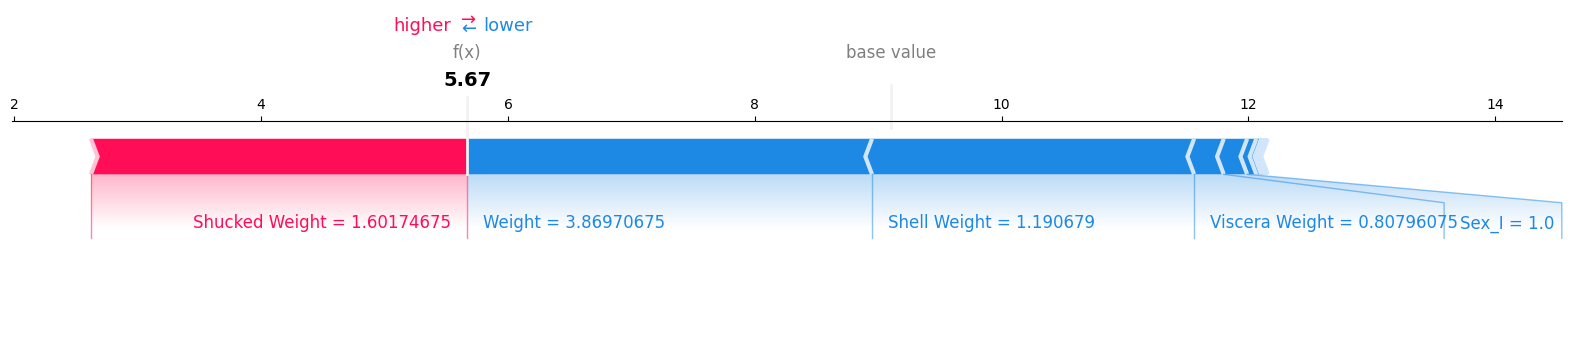

In [ ]:
#Run this code as it is
ex = KernelExplainer(svr.predict, sample(X_train, 10))  #only taking sample of 10 values for now
shap_values = ex.shap_values(X_test.iloc[0,:]) #explaining 1st tuple of the X_test dataframe
force_plot(ex.expected_value, shap_values, X_test.iloc[0,:], matplotlib=True)

Can you see how the above plot visualizes which parameters contributed significantly to the prediction, and what were the actual values which led to the prediction?

##Classification

In the below cells, we are going to implement K Nearest Neighbour Classification.

Link to the dataset is here - https://drive.google.com/file/d/1LlLZM-DCdajm9-EakRLM7qJSYQghJZUW/view?usp=sharing <br>

Import the 'classified_data.txt' dataset using pandas and print the first five columns.

Use "index_col" parameter to index the dataframe according to the first column. Otherwise, a new column would get created. Call this new dataframe 'df'.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/classified_data.txt',index_col=0)
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


If you're wondering what these column names signify, well they are classified as the dataset name suggests. Our job here is to simply take the data at face value and build a model for classifying the target classes.

###Basic EDA

In the following two cells, use info() and describe() to get the data type and statistical summary of the dataset

In [ ]:
#info()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   WTT           1000 non-null   float64
 1   PTI           1000 non-null   float64
 2   EQW           1000 non-null   float64
 3   SBI           1000 non-null   float64
 4   LQE           1000 non-null   float64
 5   QWG           1000 non-null   float64
 6   FDJ           1000 non-null   float64
 7   PJF           1000 non-null   float64
 8   HQE           1000 non-null   float64
 9   NXJ           1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 93.8 KB


In [ ]:
#describe()
df.describe()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,0.949682,1.114303,0.834127,0.682099,1.032336,0.943534,0.963422,1.071960,1.158251,1.362725,0.50000
std,0.289635,0.257085,0.291554,0.229645,0.243413,0.256121,0.255118,0.288982,0.293738,0.204225,0.50025
min,0.174412,0.441398,0.170924,0.045027,0.315307,0.262389,0.295228,0.299476,0.365157,0.639693,0.00000
25%,0.742358,0.942071,0.615451,0.515010,0.870855,0.761064,0.784407,0.866306,0.934340,1.222623,0.00000
50%,0.940475,1.118486,0.813264,0.676835,1.035824,0.941502,0.945333,1.065500,1.165556,1.375368,0.50000
75%,1.163295,1.307904,1.028340,0.834317,1.198270,1.123060,1.134852,1.283156,1.383173,1.504832,1.00000
max,1.721779,1.833757,1.722725,1.634884,1.650050,1.666902,1.713342,1.785420,1.885690,1.893950,1.00000


**Run a 'for' loop to draw boxplots of all the features for '0' and '1' TARGET CLASS**<br>
Hint: Loop through each of the 10 features and draw a separate boxplot. You should have 10 boxplots in total. <br>
Refer seaborn boxplot() documentation

Here is some information about boxplots:

Understanding Boxplots:
https://medium.com/analytics-vidhya/introduction-to-box-plots-and-how-to-interpret-them-22464acbcba7 <br>
Comparing two boxplots: https://www.nagwa.com/en/explainers/812192146073/

In [ ]:
df.columns

Index(['WTT', 'PTI', 'EQW', 'SBI', 'LQE', 'QWG', 'FDJ', 'PJF', 'HQE', 'NXJ',
       'TARGET CLASS'],
      dtype='object')

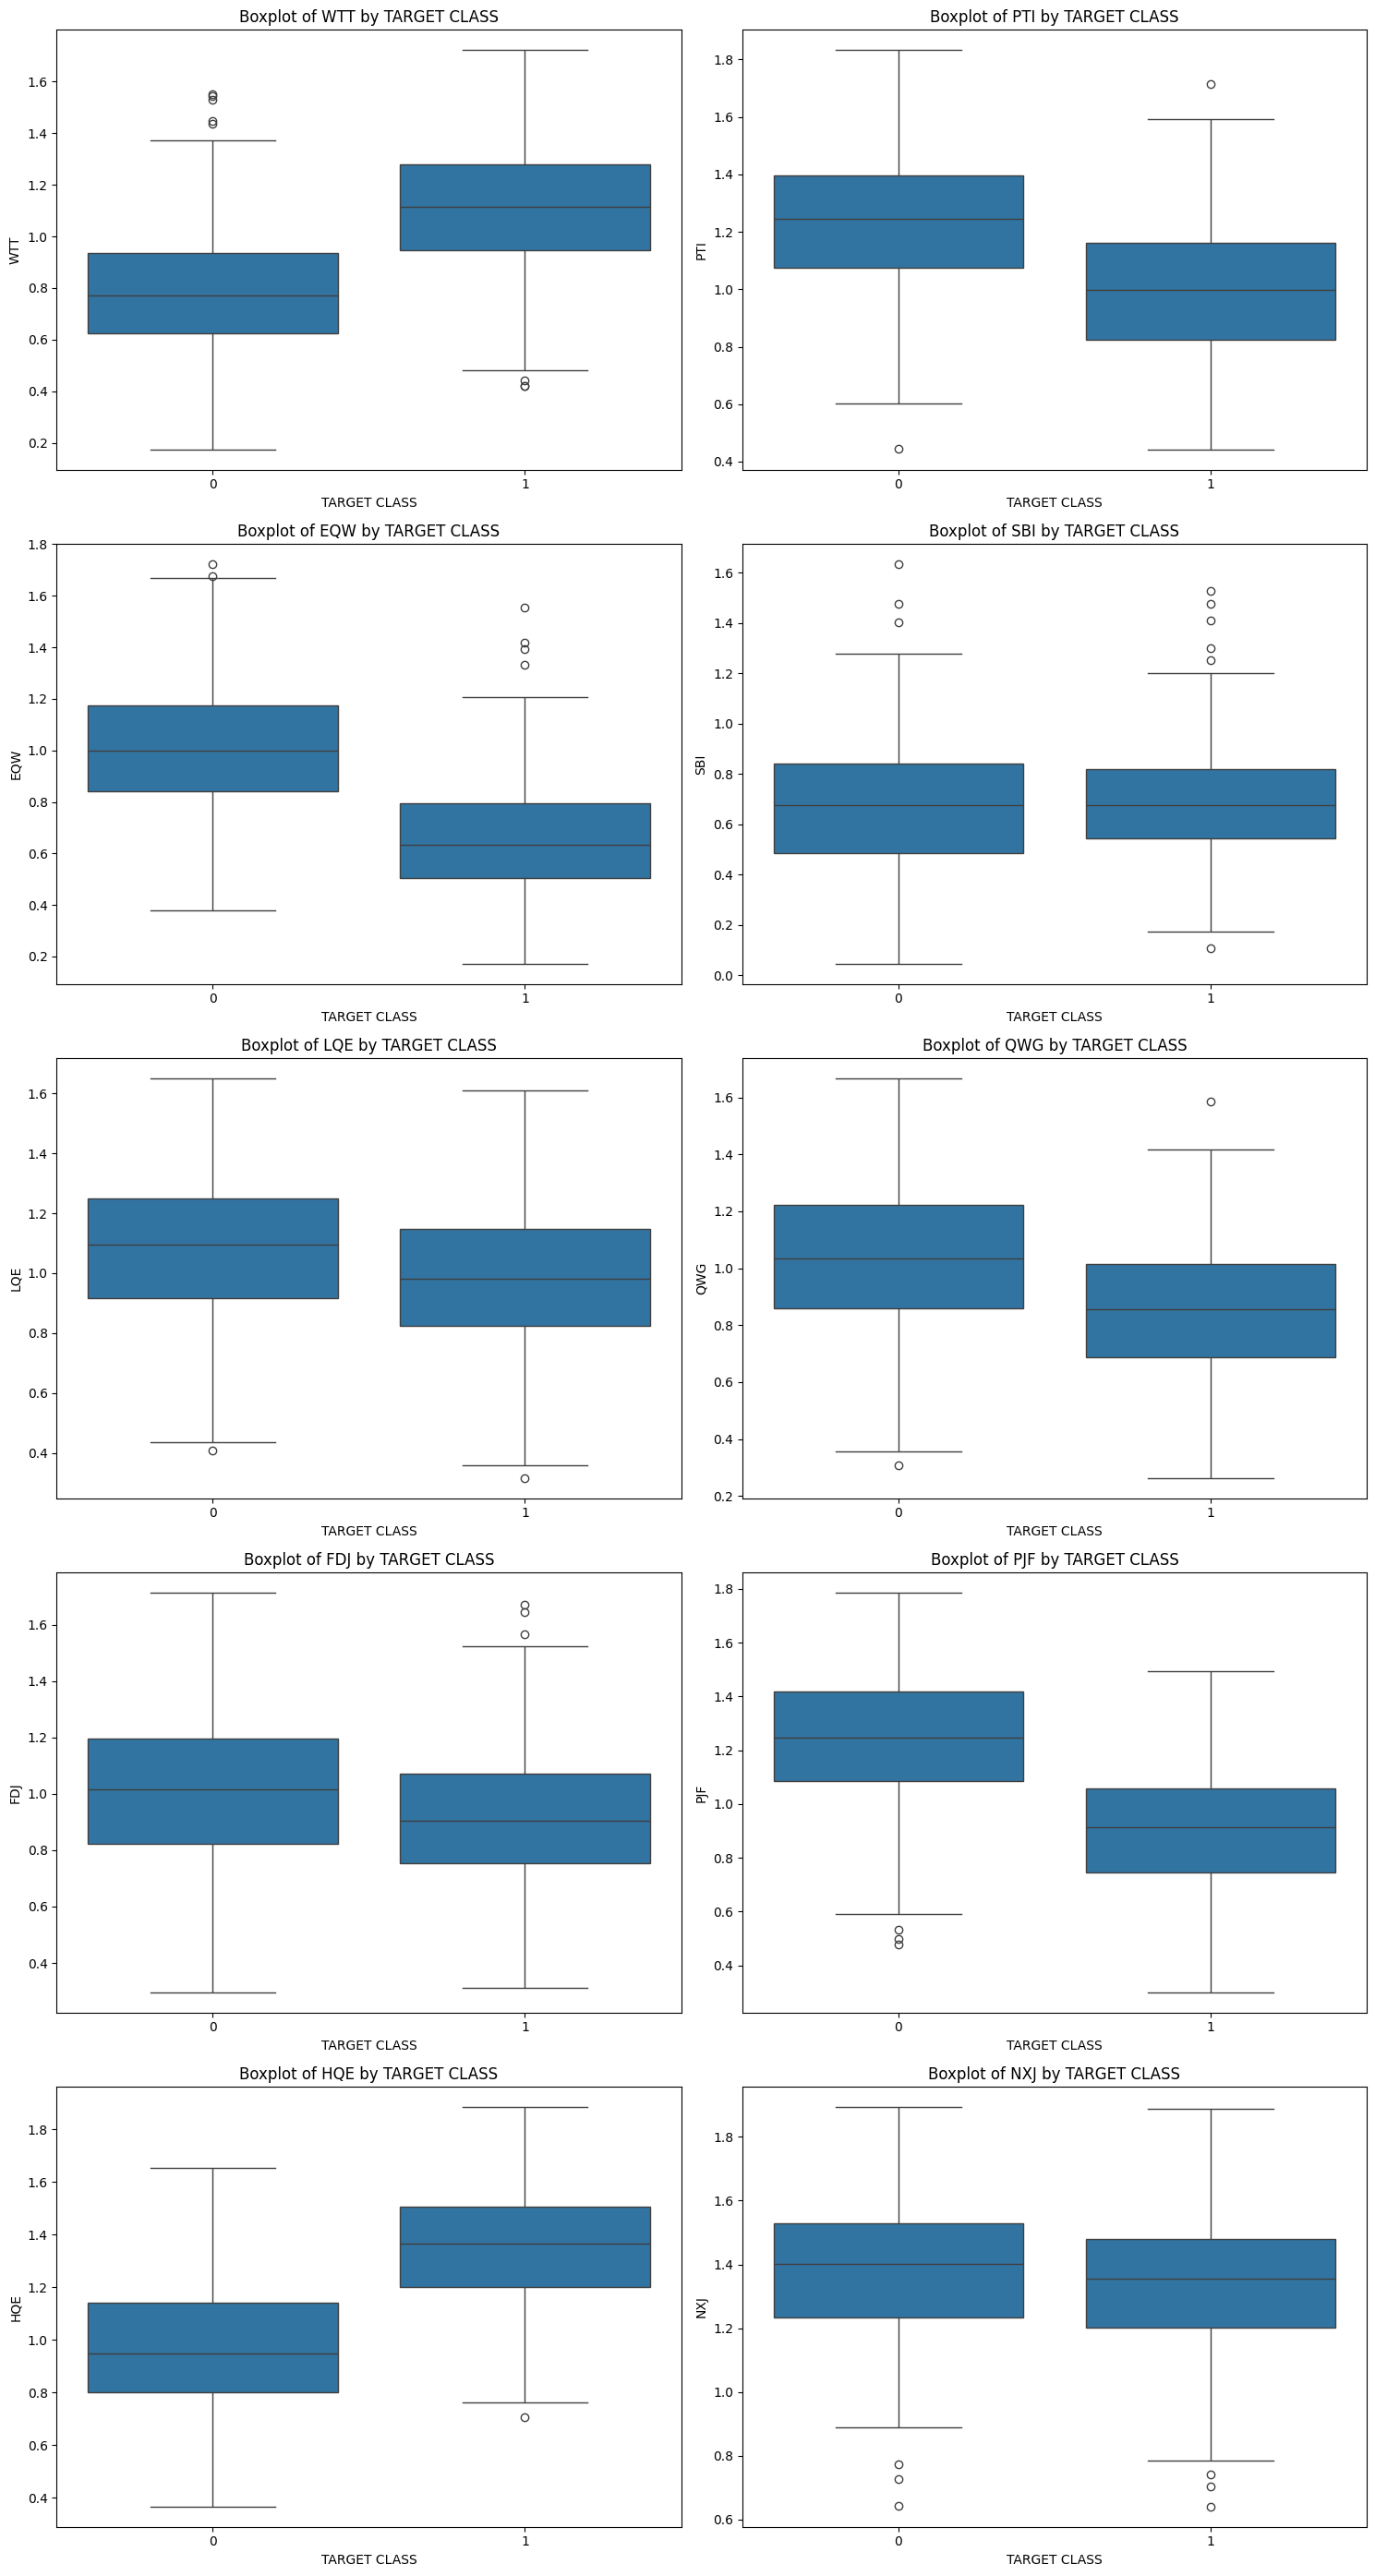

In [ ]:
# your code starts here

features = [col for col in df.columns if col != 'TARGET CLASS']

plt.figure(figsize=(15, 28))

for i, feature in enumerate(features):
    plt.subplot(5, 2, i+1)
    sns.boxplot(x='TARGET CLASS', y=feature, data=df)
    plt.title(f'Boxplot of {feature} by TARGET CLASS')
    plt.xlabel('TARGET CLASS')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()
# your code ends here

What conclusion, if any can you draw from these boxplots?
List them down below.

Text here

### Standardize the features using sklearn.preprocessing
Why should we standardize?<br>
Variables that are measured at different scales do not contribute equally to the model fitting & model learned function and might end up creating a bias. Thus, to deal with this potential problem feature-wise standardization is usually used prior to model fitting.<br><br>

To give you an example, values pertaining to Age usually lie within the range of 1-100, however values pertaining to Salary lie in a much wider range of say 10000-1000000. You can see how having both columns be a part of a classification model as is would lead to an imbalance in importance assigned to columns.
<br><br>
Go through this link for a better understanding:<br>
https://towardsdatascience.com/how-and-why-to-standardize-your-data-996926c2c832

**import StandardScaler from Sklearn and instantiate it to a variable called "scaler"**

In [ ]:
# your code starts here
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# your code ends here

**Fit only the features data to this scaler (leaving the TARGET CLASS column out) and then transform**<br>
Hint: scaler.fit() and scaler.transform()

In [ ]:
feature_columns = [col for col in df.columns if col != 'TARGET CLASS']


scaled_features = scaler.fit_transform(df[feature_columns])


scaled_df = pd.DataFrame(scaled_features, columns=feature_columns, index=df.index)

In [ ]:
# your code starts here
# your code ends here

**scaler.transform() will return an array. We need to convert this into a dataframe. Do this and add the column names to the dataframe. Call this new dataframe as "df_feat". Call head() on this df**<br>
Note: The final dataframe will have the initial columns except the "TARGET CLASS".

In [ ]:
# your code starts here

df_feat = pd.DataFrame(scaled_features, columns=feature_columns, index=df.index)


print(df_feat.head())

# your code ends here

        WTT       PTI       EQW       SBI       LQE       QWG       FDJ  \
0 -0.123542  0.185907 -0.913431  0.319629 -1.033637 -2.308375 -0.798951   
1 -1.084836 -0.430348 -1.025313  0.625388 -0.444847 -1.152706 -1.129797   
2 -0.788702  0.339318  0.301511  0.755873  2.031693 -0.870156  2.599818   
3  0.982841  1.060193 -0.621399  0.625299  0.452820 -0.267220  1.750208   
4  1.139275 -0.640392 -0.709819 -0.057175  0.822886 -0.936773  0.596782   

        PJF       HQE       NXJ  
0 -1.482368 -0.949719 -0.643314  
1 -0.202240 -1.828051  0.636759  
2  0.285707 -0.682494 -0.377850  
3  1.066491  1.241325 -1.026987  
4 -1.472352  1.040772  0.276510  


### Train/Test split

**Set X to be equal to df_feat and set y accordingly. As you know, X contains our training features and y contains our target.**<br>
Hint: y can be taken directly from the initial dataframe "df"

In [ ]:
# Your code starts here.
X = df_feat.copy()
y = df["TARGET CLASS"].copy()

# Your code ends here

**Import train_test_split function from scikit-learn**<br>
**Create X and y train and test splits in one command using a test size of 0.3 and a random seed**<br>
They should be called X_train, X_test, y_train, y_test

In [ ]:
# Your code starts here.
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
# Your code ends here

### Model fit and training

Before moving ahead with the cells below, learn how the K Nearest Neighbour Algorithm actually works.

Theory and implementation : https://youtu.be/wTF6vzS9fy4 <br>
Theory: https://www.analyticsvidhya.com/blog/2018/08/k-nearest-neighbor-introduction-regression-python/

**import KNeighborsClassifier from sklearn and initialize it with neighbours = 1 (more on this later) . Fit this on X_train and y_train**

In [ ]:
# Your code starts here.
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train,y_train)

# Your code ends here

KNeighborsClassifier(n_neighbors=1)

**Using this fitted model, predict on X_test. Store these predictions in variable called pred.**

In [ ]:
# Your code starts here.
pred = knn.predict(X_test)
# Your code ends here

**Let us check how correct these predictions are.<br>
Print a classification report of y_test and pred**<br>
Hint: sklearn classification_report

In [72]:
# Your code starts here.
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))
# Your code ends here

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       142
           1       0.95      0.93      0.94       158

    accuracy                           0.94       300
   macro avg       0.94      0.94      0.94       300
weighted avg       0.94      0.94      0.94       300



Learn all about classification metrics - https://medium.com/analytics-vidhya/evaluation-metrics-for-classification-models-e2f0d8009d69

**Print the accuracy using numpy and round it to 3 decimal places.**

In [73]:
# Your code starts here.
import numpy as np

accuracy = np.mean(pred == y_test)
print("Accuracy:", round(accuracy, 3))
# Your code ends here

Accuracy: 0.937


Hey, not bad! But can we further improve this? Remember our arbitrary choice for n_neighbours? Can we improve that?

### Choosing optimal 'k'

**Above, we chose n_neighbours to be equal to 1. Choosing a small value of K leads to unstable decision boundaries. <br>
We need to select n_neighbours by calculating the accuracy for every value of n from 1 to 60 and then choosing the one which gives the highest accuracy.**

In [74]:
# Do the same as we did above, but this time make a loop from n = 1 to n = 60 and append the accuracy
# for each in a list

# Your code starts here.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

accuracies = []

# Loop through k values from 1 to 60
for n in range(1, 61):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    pred_n = knn.predict(X_test)
    acc = np.mean(pred_n == y_test)
    accuracies.append(acc)


best_k = np.argmax(accuracies) + 1
print(f'Best k: {best_k} with accuracy {round(accuracies[best_k - 1], 3)}')



# Your code ends here

Best k: 12 with accuracy 0.953


**Plot a graph of K value vs Accuracy**

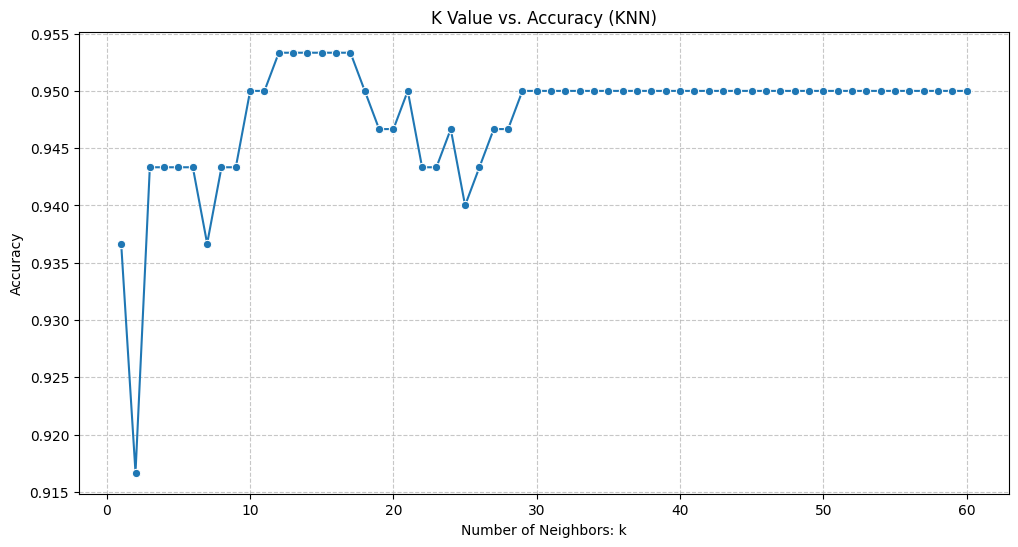

In [75]:
# Your code starts here.
import seaborn as sns



df_plot = pd.DataFrame({'k': range(1, 61), 'accuracy': accuracies})

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='k', y='accuracy', marker='o')
plt.xlabel('Number of Neighbors: k')
plt.ylabel('Accuracy')
plt.title('K Value vs. Accuracy (KNN)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Your code ends here

**Choose the best value of n_neighbours and give a reason why and also print the accuracy**

In [76]:
# Your code starts here.

best_k = df_plot['k'][df_plot['accuracy'].idxmax()]
best_acc = df_plot['accuracy'].max()
print(f"Best number of neighbors (k): {best_k}")
print(f"Highest Accuracy: {round(best_acc, 3)}")

# Your code ends here

Best number of neighbors (k): 12
Highest Accuracy: 0.953


In [ ]:
# Reasons:
# The best value of n_neighbors is the one that yields the highest accuracy on your test data.

# Using too small a k (like 1) may lead to high variance ("unstable decision boundaries"), being sensitive to noise/outliers.

# Using too large a k can cause over-smoothing and underfitting.

# The optimal k balances bias and variance, giving high and stable accuracy.

# **Compulsory:**

Task 1 : You have to research and create a short blog on the topic of **Reinforcement Learning**.


Task 2 : You have to research and create a short blog on the topic of **Oversampling and Undersampling**.
Happy coding! :)

Task 1: A Short Blog on Reinforcement Learning

What is Reinforcement Learning?
Reinforcement Learning (RL) is an area of machine learning where an agent learns to make decisions by interacting with an environment. The agent's goal is to take actions that maximize cumulative reward over time.

How Does RL Work?

The agent observes the current state of the environment.

It selects an action based on its current policy.

The environment transitions to a new state and provides a reward.

The agent updates its policy based on the reward received.

Key Concepts:

Agent: The learner/decision maker.

Environment: Where the agent operates.

Action: Choice made by the agent.

Reward: Feedback from the environment targeting the agent’s objective.

Policy: The agent’s strategy for choosing actions.

Value Function: Estimates how good a state (or action) is in terms of expected cumulative reward.

Exploration vs Exploitation: The trade-off between trying new things and using known strategies for reward.

Popular Algorithms:

Q-learning

Deep Q-Networks (DQN)

Policy Gradient Methods

Proximal Policy Optimization (PPO)

Applications:
Reinforcement learning powers game AI (e.g., AlphaGo), robotics, recommendation systems, self-driving cars, and automated trading.

Summary:
RL is powerful because it enables learning complex behaviors without explicit programming, using trial and error guided by reward signals.

Task 2: A Short Blog on Oversampling and Undersampling

What are Oversampling and Undersampling?
These are techniques to address class imbalance in datasets. Class imbalance happens when some classes have significantly more samples than others (e.g., 95% negative and 5% positive labels).

Why is this a problem?
Machine learning models trained on imbalanced data risk being biased toward the majority class, leading to poor predictions for the minority class.

Oversampling:

Definition: Increasing the number of samples in the minority class.

Methods:

Random Oversampling: Duplicate existing minority samples.

SMOTE (Synthetic Minority Over-sampling Technique): Create synthetic samples by interpolating between minority class instances.

Undersampling:

Definition: Reducing the number of samples in the majority class.

Methods:

Random Undersampling: Randomly remove samples from the majority class.

Cluster Centroids: Replace clusters of majority samples with a centroid.

When to use which?

Use oversampling when you have limited data and risk overfitting.

Use undersampling when you have lots of majority class data, but beware of losing important information.

Best Practices:

Often, a combination (e.g., SMOTE + undersampling) works best.

Always validate changes with cross-validation to avoid overfitting.

# **End of Task**


